# **Philly-Style Data Science Project Report**

**Problem Statement:**

With the growth of Spotify, and the accesbility of independent music production equipment, millions of tracks are released on the platform each year, but predicting which songs and artists will become popular remains a challenge even for industry insiders. Spotify provides extensive audio features and metadata for every track, yet it is not always clear which factors most strongly influence a track’s success. As a result, artists, producers, record labels, and Spotify itself may miss opportunities for targeted promotion and resource allocation. This project leverages Spotify’s data to predict track popularity on the platform and identify the audio features and metadata that most significantly drive success. To achieve this objective, the project will use an existing Kaggle dataset containing historical Spotify track metadata, as the newer Spotify API no longer provides this metadata. The dataset will first be explored and filtered to ensure quality and relevance. Following this, three predictive models will be trained to estimate track popularity: a k-nearest neighbors (KNN) model to predict popularity based on similarity in metadata, a support vector regression (SVR) model, and a logistic regression model. The performance of these models will be compared to identify which approach most effectively predicts track popularity and to determine which of the features has the strongest influence on a track’s success.

**The Dataset:**

The dataset used in this project was a six-year old dataset from Kaggle curated by Zaheen Hamidani. This is because Spotify API no longer provides several key variables, being limited to basic music metadata. To train our machine learning models to more accurately predict a song’s popularity, it was essential to use a dataset that included these variables.

The dataset used contained approximately 232,000 samples and 18 features, each sample representing a Spotify track. These features include musical characteristics, such as tempo and valence, as well as metadata attributes, such as artist and genre.


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zaheenhamidani/ultimate-spotify-tracks-db")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ultimate-spotify-tracks-db' dataset.
Path to dataset files: /kaggle/input/ultimate-spotify-tracks-db


**Methodology:**

The target variable selected for prediction was popularity. The tools used for data analysis included a variety of supervised machine learning models trained to predict popularity. Specifically, K-Nearest Neighbors (KNN), Support Vector Machines (SVM), and Gradient Boosting Regressors were all employed. Categorical features, including Mode, Key, and Genre, were one-hot encoded, and numerical data was z scored to prevent feature dominance based on scaling differences.

**Pre-Processing Data:**

In addition to running the models on the original dataset, we retested after excluding the artist column which was shown to be an overdominant feature, and we subsequently removed all tracks with popularity over 70 for a third test. This approach eliminated the influence of the most popular artists, and allowed the models to be trained without associating variables with artist identity, focusing exclusively on the correlation between the remaining features and song popularity. This step is important because it removes the inherent bias associated with artists who have already received significant support from major labels and music publishers. With this bias eliminated, we then focused exclusively on the features that predict a song’s popularity. This approach enables the prediction of an emerging artist’s potential for success, based solely on song characteristics, without considering their current fanbase or image.ode, Key, and Genre, were one-hot encoded, and numerical data was z scored to prevent feature dominance based on scaling differences.

Two important pre-processing decisions were how to handle text features and categorical features. Artist name was target-encoded to the average artist popularity, based on the assumption that an artist’s personal brand recognition is the primary statistical significance of an artist’s identity. Track name was removed because it would require too large an expansion of training time to encode for presumably little gain. All categorical features were one-hot encoded to enable the ML models to work with them. All features were z-scored since SVR is sensitive to numerical magnitude.

In [ ]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

import pandas as pd
import numpy as np

import os

file_path = os.path.join(path, "SpotifyFeatures.csv")
df = pd.read_csv(file_path)

# Standardize 'Children’s Music' to 'Children's Music'
df['genre'] = df['genre'].replace("Children’s Music", "Children's Music")

y_df = df['popularity']
x_df = df.drop(['popularity', 'track_id'], axis=1)

# Select the 'mode', 'key', and 'genre' columns for one-hot encoding
mode_column = x_df[['mode']]
key_column = x_df[['key']]
genre_column = x_df[['genre']]
time_signature = x_df[['time_signature']]

# Initialize separate OneHotEncoder instances for each column
mode_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
key_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
genre_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
time_signature_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# One-hot encode 'mode', 'key', and 'genre' columns using their respective encoders
encoded_mode = mode_encoder.fit_transform(mode_column)
encoded_key = key_encoder.fit_transform(key_column)
encoded_genre = genre_encoder.fit_transform(genre_column)
encoded_time_signature = time_signature_encoder.fit_transform(time_signature)

# Create DataFrames from the one-hot encoded outputs with appropriate column names
encoded_mode_df = pd.DataFrame(encoded_mode, columns=mode_encoder.get_feature_names_out(['mode']))
encoded_key_df = pd.DataFrame(encoded_key, columns=key_encoder.get_feature_names_out(['key']))
encoded_genre_df = pd.DataFrame(encoded_genre, columns=genre_encoder.get_feature_names_out(['genre']))
encoded_time_signature_df = pd.DataFrame(encoded_time_signature, columns=time_signature_encoder.get_feature_names_out(['time_signature']))

# Drop the original 'mode', 'key', and 'genre' columns from x_df
x_df = x_df.drop(['mode', 'key', 'genre', 'time_signature'], axis=1)

# Concatenate the one-hot encoded DataFrames with the rest of x_df
x_df_processed = pd.concat([x_df.reset_index(drop=True), encoded_mode_df, encoded_key_df, encoded_genre_df, encoded_time_signature_df], axis=1)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(x_df_processed, y_df, test_size=0.2, random_state=42, shuffle=True)

# TF-IDF vectorise the album name to find wods or phrases that might be popular (Abandoned due to training time complications)
#tfidf = TfidfVectorizer(max_features=300,stop_words='english',ngram_range=(1, 2),token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z]+\b')
#tfidf_train = tfidf.fit_transform(X_train['track_name'].fillna(''))
#tfidf_test = tfidf.transform(X_test['track_name'].fillna(''))
#tfidf_train_df = pd.DataFrame(tfidf_train.toarray(), columns=[f"track_tfidf_{c}" for c in tfidf.get_feature_names_out()])
#tfidf_test_df = pd.DataFrame(tfidf_test.toarray(), columns=[f"track_tfidf_{c}" for c in tfidf.get_feature_names_out()])
X_train = X_train.drop('track_name', axis=1)
X_test = X_test.drop('track_name', axis=1)

# Target Encoding the artist collumn to become the average of a artists popularity accross all their scores
# Justified by the fact that the most important characteristic of a artist name is brand recognition
artist_mean = X_train.join(y_train).groupby('artist_name')['popularity'].mean()
global_mean = y_train.mean()
X_train['artist_target'] = X_train['artist_name'].map(artist_mean).fillna(global_mean)
X_test['artist_target'] = X_test['artist_name'].map(artist_mean).fillna(global_mean)
X_train = X_train.drop('artist_name', axis=1)
X_test = X_test.drop('artist_name', axis=1)

# Post Split Concat
#X_train_processed = pd.concat([X_train.reset_index(drop=True), tfidf_train_df.reset_index(drop=True)], axis=1)
#X_test_processed = pd.concat([X_test.reset_index(drop=True), tfidf_test_df.reset_index(drop=True)],axis=1)
X_train_processed = X_train
X_test_processed = X_test

#pd.set_option('display.max_columns', None)

pd.set_option('display.max_rows', None)
print(X_train_processed.dtypes)

# To Numpy for scikit-learn models
x_train = X_train_processed.to_numpy()
x_test = X_test_processed.to_numpy()
y_train_arr = y_train.to_numpy()
y_test_arr = y_test.to_numpy()

# Scale beffore PCA so some values dont dominate
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Apply PCA
# pca = PCA(n_components=0.95)
# x_train_pca = pca.fit_transform(x_train_scaled)
# x_test_pca = pca.transform(x_test_scaled)
# print("PCA train shape:", x_train_pca.shape)
# print("PCA test shape:", x_test_pca.shape)

def evaluate_model(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_true, y_pred)
    print(f"{name} -> RMSE: {rmse:.2f}, R2: {r2:.4f}")

feature_names = X_train_processed.columns.tolist()

acousticness              float64
danceability              float64
duration_ms                 int64
energy                    float64
instrumentalness          float64
liveness                  float64
loudness                  float64
speechiness               float64
tempo                     float64
valence                   float64
mode_Major                float64
mode_Minor                float64
key_A                     float64
key_A#                    float64
key_B                     float64
key_C                     float64
key_C#                    float64
key_D                     float64
key_D#                    float64
key_E                     float64
key_F                     float64
key_F#                    float64
key_G                     float64
key_G#                    float64
genre_A Capella           float64
genre_Alternative         float64
genre_Anime               float64
genre_Blues               float64
genre_Children's Music    float64
genre_Classica

**Dataset Overview:**

Our dataset consisted of 232,000 samples with 18 features (both numerical and categorical). During EDA we noticed a practice of artists submitting the same song under several genres - boosting the amount of times that track ID appears. Example shown below under categorical data.


In [ ]:
#Numeric Summary
numeric_summary = df.select_dtypes(include=['number']).describe().T
print(numeric_summary)

                     count           mean            std          min  \
popularity        232725.0      41.127502      18.189948      0.00000   
acousticness      232725.0       0.368560       0.354768      0.00000   
danceability      232725.0       0.554364       0.185608      0.05690   
duration_ms       232725.0  235122.339306  118935.909299  15387.00000   
energy            232725.0       0.570958       0.263456      0.00002   
instrumentalness  232725.0       0.148301       0.302768      0.00000   
liveness          232725.0       0.215009       0.198273      0.00967   
loudness          232725.0      -9.569885       5.998204    -52.45700   
speechiness       232725.0       0.120765       0.185518      0.02220   
tempo             232725.0     117.666585      30.898907     30.37900   
valence           232725.0       0.454917       0.260065      0.00000   

                          25%            50%          75%          max  
popularity            29.0000      43.000000      

In [ ]:
#Catagorical Summary
cat_summary = df.select_dtypes(include=['object','category']).describe().T
print(cat_summary)

#A Look At A Repeated Submission
rows = df[df['track_id'] == '6sVQNUvcVFTXvlk3ec0ngd']
print(rows)

                 count  unique                     top    freq
genre           232725      26        Children's Music   14756
artist_name     232725   14564          Giuseppe Verdi    1394
track_name      232724  148614                    Home     100
track_id        232725  176774  6sVQNUvcVFTXvlk3ec0ngd       8
key             232725      12                       C   27583
mode            232725       2                   Major  151744
time_signature  232725       5                     4/4  200760
                   genre    artist_name            track_name  \
10230        Alternative  Cocteau Twins  Cherry-coloured Funk   
20391              Dance  Cocteau Twins  Cherry-coloured Funk   
22947         Electronic  Cocteau Twins  Cherry-coloured Funk   
44871               Folk  Cocteau Twins  Cherry-coloured Funk   
102041  Children's Music  Cocteau Twins  Cherry-coloured Funk   
141335             Indie  Cocteau Twins  Cherry-coloured Funk   
153467              Rock  Cocteau Twins  

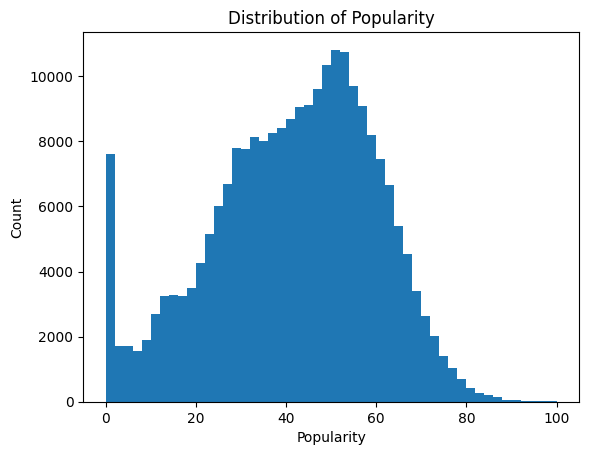

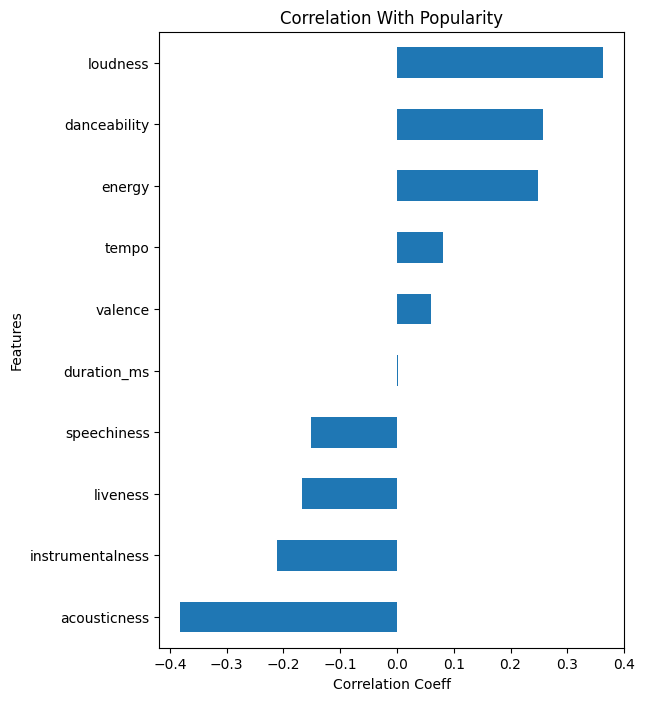

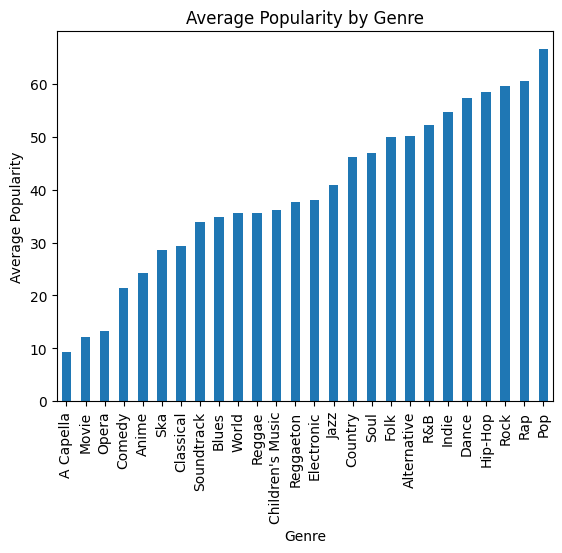

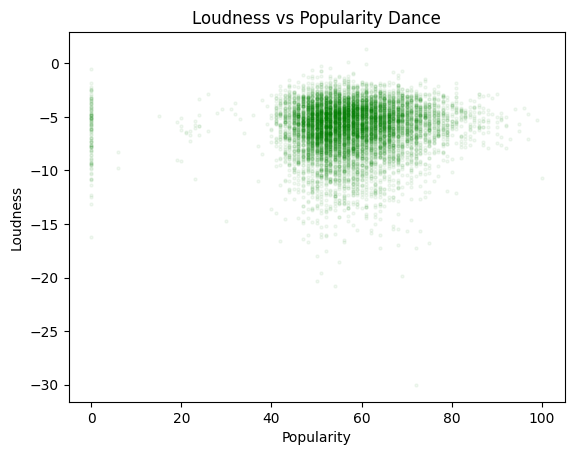

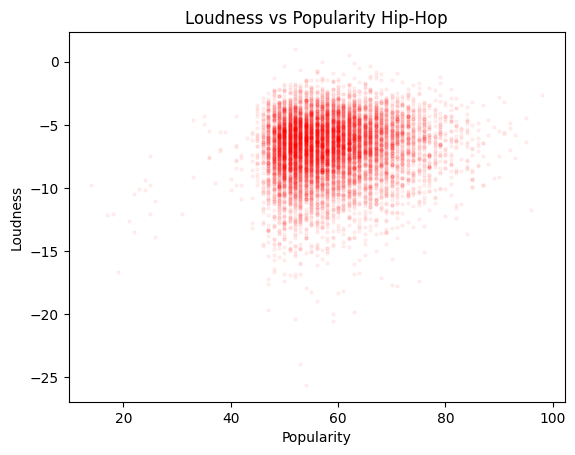

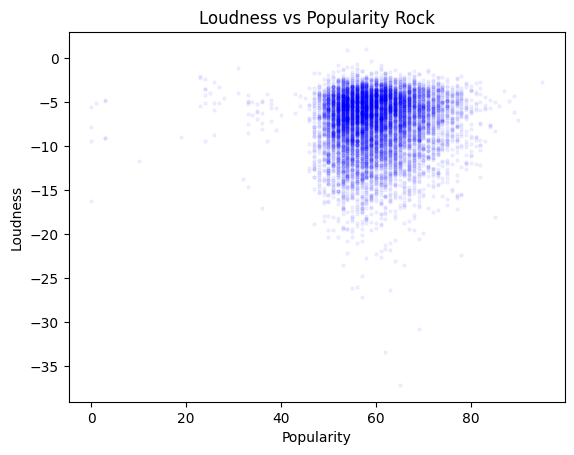

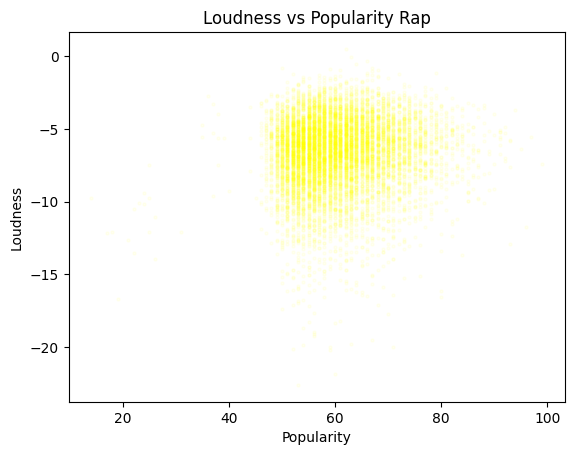

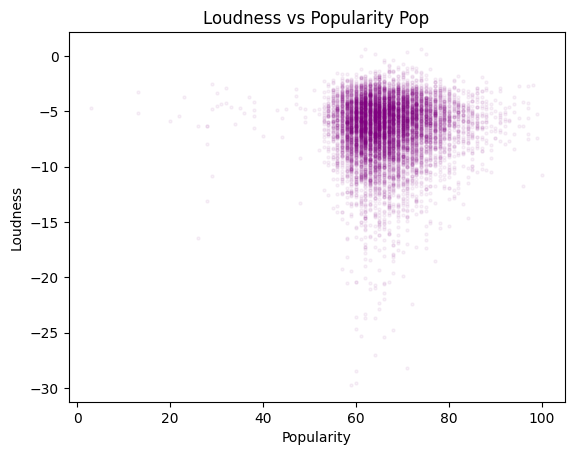

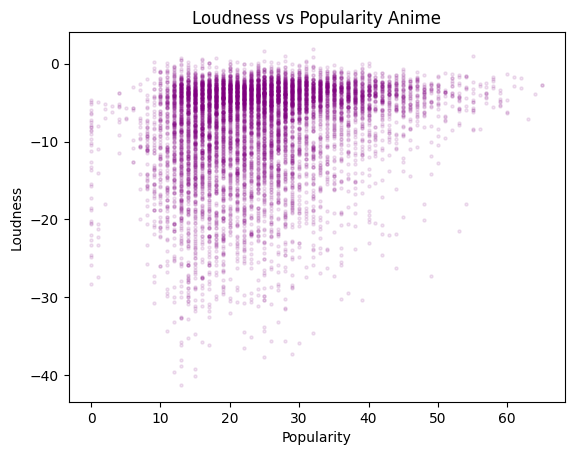

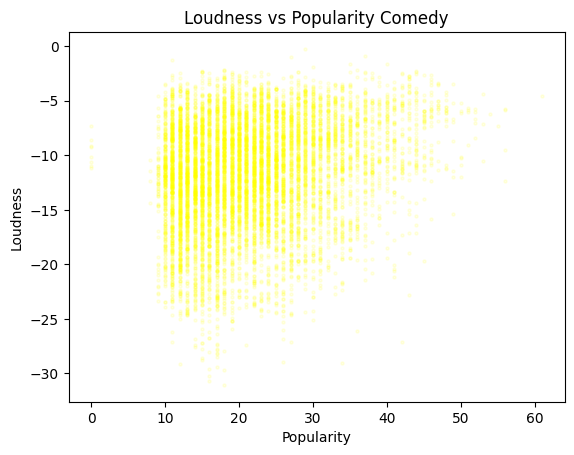

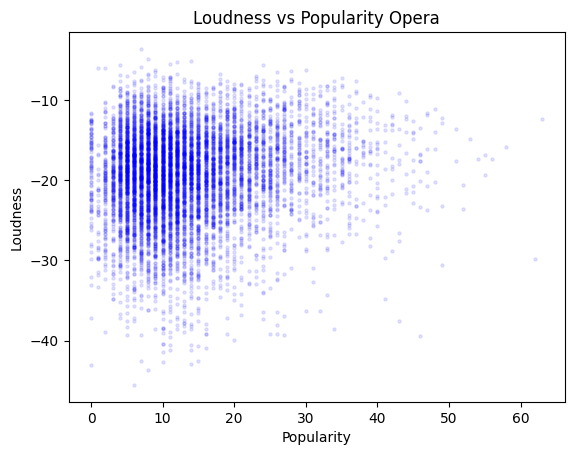

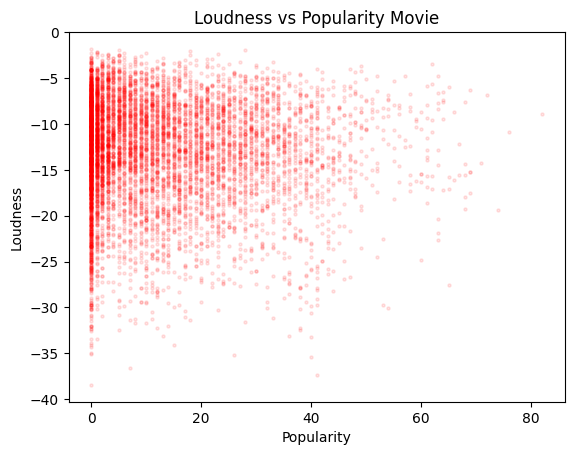

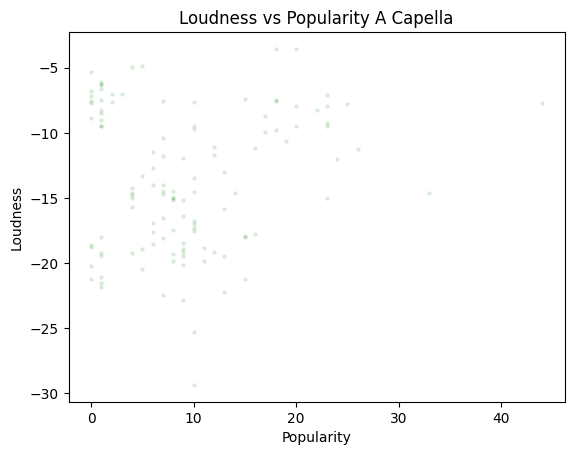

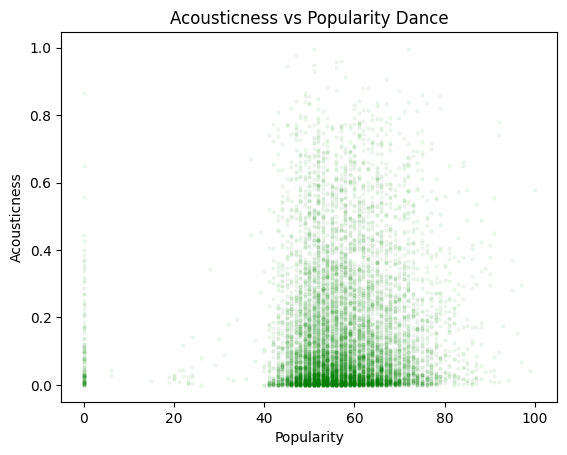

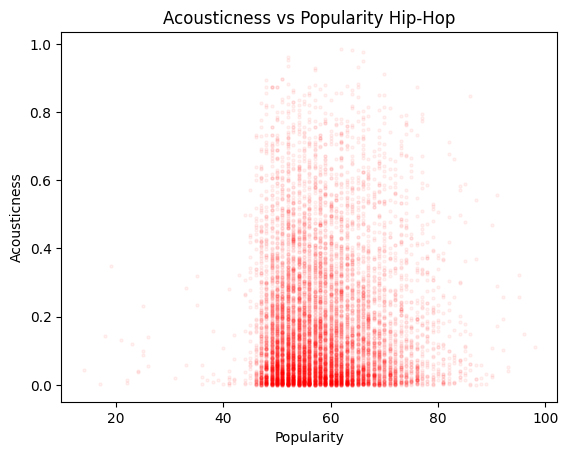

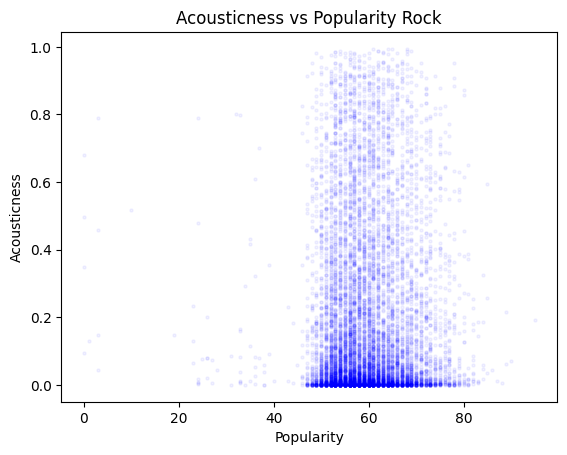

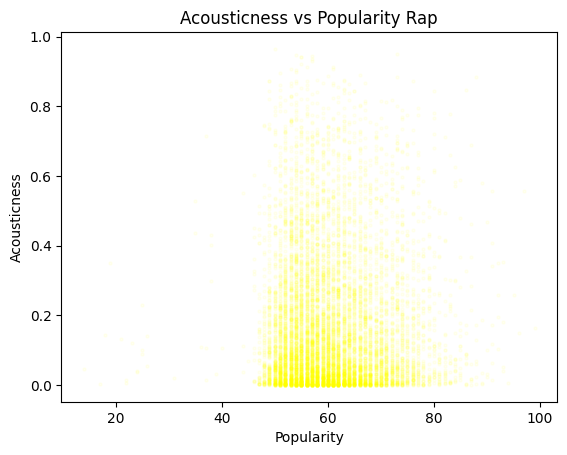

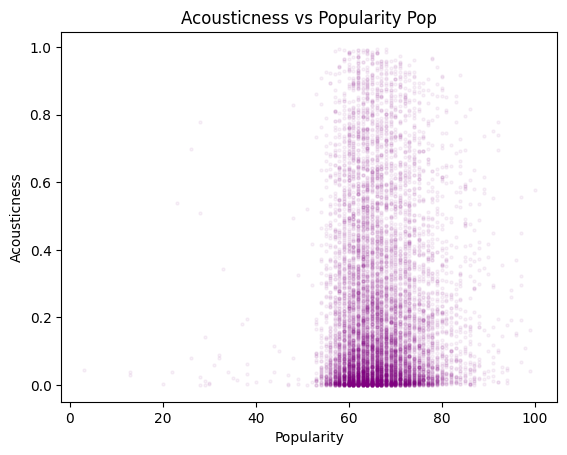

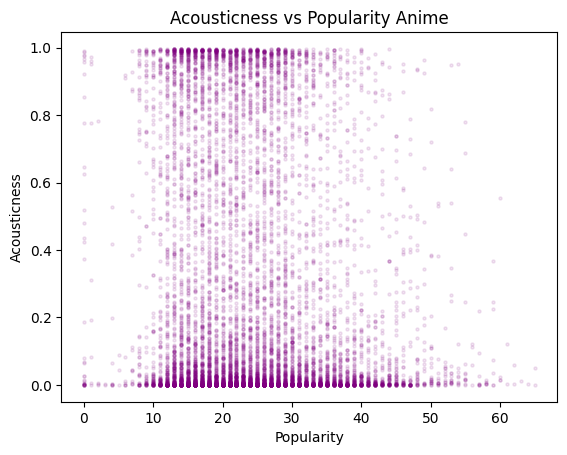

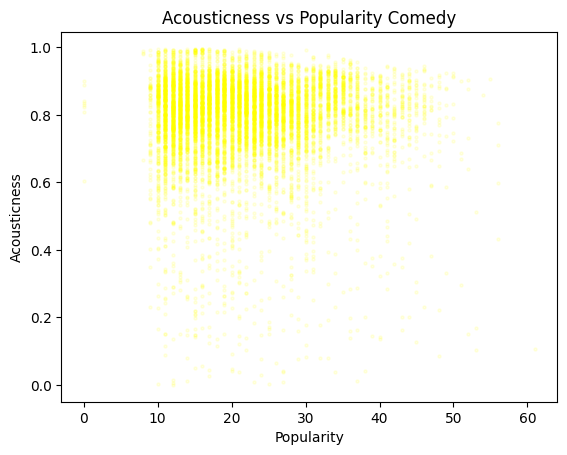

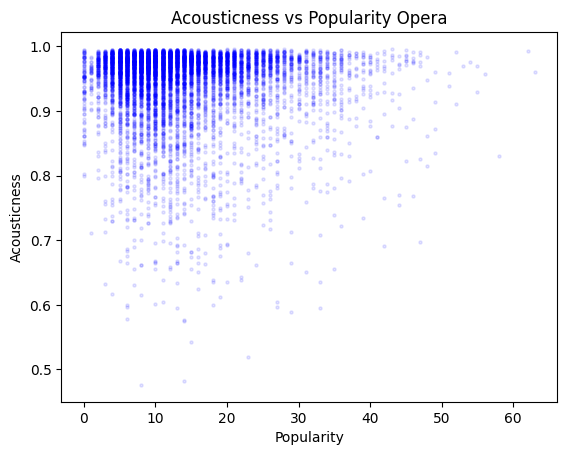

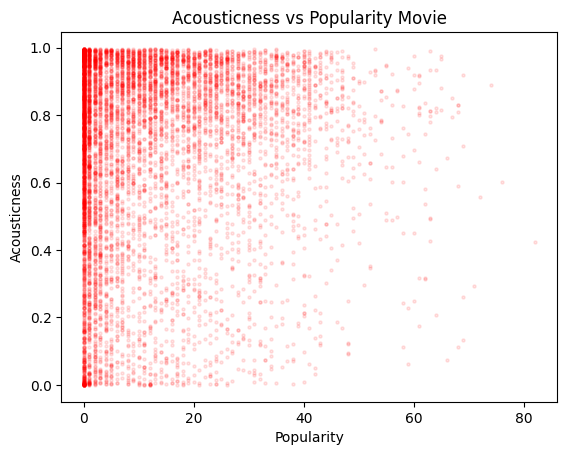

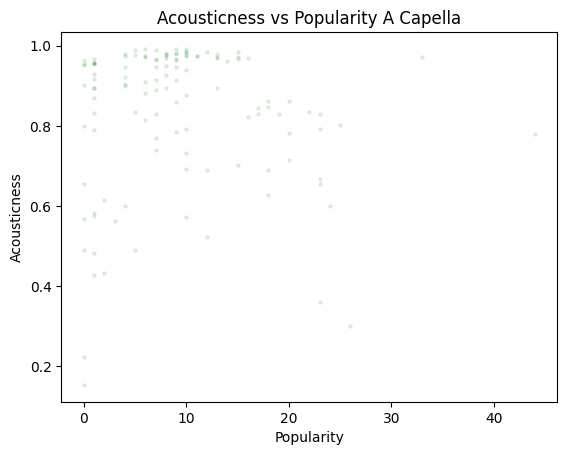

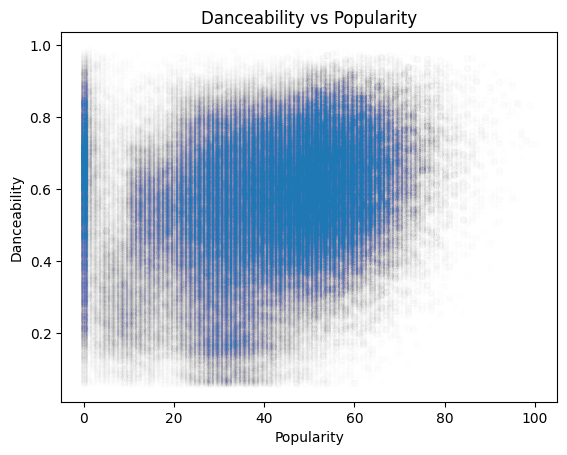

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

# #Initial Look at popularity distribution
plt.hist(df['popularity'], bins=50)
plt.title('Distribution of Popularity')
plt.xlabel('Popularity')
plt.ylabel('Count')
plt.show()

# #Key Numeric Features Versus Popularity
Corr = df.corr(numeric_only=True)['popularity'].sort_values()

plt.figure(figsize=(6,8))
Corr.drop('popularity').plot(kind='barh')
plt.title('Correlation With Popularity')
plt.xlabel('Correlation Coeff')
plt.ylabel('Features')
plt.show()

# #Avg Pop by Genre
df.groupby('genre')['popularity'].mean().sort_values().plot(kind='bar')
plt.title('Average Popularity by Genre')
plt.xlabel('Genre')
plt.ylabel('Average Popularity')
plt.show()

#Loudness By Popularity For Top 5 Genres

def get_top_bottom_5_genres(df, x_col, y_col, x_label, y_label, graph_label):
    most_popular_genres = df.groupby('genre')['popularity'].mean().sort_values().tail(5).index.to_list()
    most_popular_df = df[df['genre'].isin(most_popular_genres)]
    least_popular_genres = df.groupby('genre')['popularity'].mean().sort_values().head(5).index.to_list()
    least_popular_df = df[df['genre'].isin(least_popular_genres)]

    colors = ['green', 'red', 'blue', 'yellow', 'purple']

    most_popular_df[most_popular_df['genre'] == most_popular_genres[0]].plot(x=x_col, y=y_col, kind='scatter', color=colors[0], s=5, alpha=0.05)
    plt.title(f'{graph_label} {most_popular_genres[0]}')
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.show()
    most_popular_df[most_popular_df['genre'] == most_popular_genres[1]].plot(x=x_col, y=y_col, kind='scatter', color=colors[1], s=5, alpha=0.05)
    plt.title(f'{graph_label} {most_popular_genres[1]}')
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.show()
    most_popular_df[most_popular_df['genre'] == most_popular_genres[2]].plot(x=x_col, y=y_col, kind='scatter', color=colors[2], s=5, alpha=0.05)
    plt.title(f'{graph_label} {most_popular_genres[2]}')
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.show()
    most_popular_df[most_popular_df['genre'] == most_popular_genres[3]].plot(x=x_col, y=y_col, kind='scatter', color=colors[3], s=5, alpha=0.05)
    plt.title(f'{graph_label} {most_popular_genres[3]}')
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.show()
    most_popular_df[most_popular_df['genre'] == most_popular_genres[4]].plot(x=x_col, y=y_col, kind='scatter', color=colors[4], s=5, alpha=0.05)
    plt.title(f'{graph_label} {most_popular_genres[4]}')
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.show()


    least_popular_df[least_popular_df['genre'] == least_popular_genres[4]].plot(x=x_col, y=y_col, kind='scatter', color=colors[4], s=5, alpha=0.1)
    plt.title(f'{graph_label} {least_popular_genres[4]}')
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.show()
    least_popular_df[least_popular_df['genre'] == least_popular_genres[3]].plot(x=x_col, y=y_col, kind='scatter', color=colors[3], s=5, alpha=0.1)
    plt.title(f'{graph_label} {least_popular_genres[3]}')
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.show()
    least_popular_df[least_popular_df['genre'] == least_popular_genres[2]].plot(x=x_col, y=y_col, kind='scatter', color=colors[2], s=5, alpha=0.1)
    plt.title(f'{graph_label} {least_popular_genres[2]}')
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.show()
    least_popular_df[least_popular_df['genre'] == least_popular_genres[1]].plot(x=x_col, y=y_col, kind='scatter', color=colors[1], s=5, alpha=0.1)
    plt.title(f'{graph_label} {least_popular_genres[1]}')
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.show()
    least_popular_df[least_popular_df['genre'] == least_popular_genres[0]].plot(x=x_col, y=y_col, kind='scatter', color=colors[0], s=5, alpha=0.1)
    plt.title(f'{graph_label} {least_popular_genres[0]}')
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.show()

get_top_bottom_5_genres(df, 'popularity', 'loudness', 'Popularity', 'Loudness', 'Loudness vs Popularity')

get_top_bottom_5_genres(df, 'popularity', 'acousticness', 'Popularity', 'Acousticness', 'Acousticness vs Popularity')


#Dance By Pop
df.plot(x='popularity', y='danceability', kind='scatter', alpha=0.005)
plt.title('Danceability vs Popularity')
plt.xlabel('Popularity')
plt.ylabel('Danceability')
plt.show()

# # Popularity Over 50% By Duration
# modulated_duration_df = df.copy()
# modulated_duration_df['modulated_duration'] = np.array([int(x / 5000) * 5000 for x in modulated_duration_df['duration_ms']])
# modulated_duration_df.where(modulated_duration_df['popularity'] > 50).plot(x='modulated_duration', kind='hist', alpha=0.5, bins=25)
# plt.title('Popularity vs Duration')
# plt.xlabel('Duration')
# plt.ylabel('Songs Popularity')
# plt.show()

**Distribution of Popularity** - Showed that scores are heavily skewed toward the lowest values (around 0), with only a small fraction of songs exceeding 80. A moderate number of songs occupy the mid-range (approximately 40 to 60). High popularity is rare, and a vast majority of songs remain largely unpopular.

**Correlation With Popularity** - Illustrates which features are most strongly associated with higher popularity scores and which features are less influential or negatively associated. The top three features contributing to higher popularity are loudness, danceability, and energy.

This reflects the findings of the 'Loudness War' (Matt Mayfield Music). This term describes a trend in which musicians increasingly use compressors to make music uniformly loud.

Acousticness, instrumentalness, and liveness appeared as the most negatively correlated. This follows logic as acoustic songs are generally quieter, and less social. Since sociability is a key factor in popularity, this aligns well with our findings.

The negative correlation between liveness and popularity is explained by listeners preference for studio recordings over live versions where the audience interferes with the clarity of the music.

In regards to instrumentalness the data suggests that songs with vocals are more memorable and engaging, contributing to their higher popularity.

In [ ]:
#Gimping our data size for weak GPU
import numpy as np

subsample_frac = 0.05
n_samples = int(len(x_train_scaled) * subsample_frac)

np.random.seed(42)
subsample_idx = np.random.choice(len(x_train_scaled), size=n_samples, replace=False)

# Subsample X and y using the same indices
x_train_scaled = x_train_scaled[subsample_idx]
y_train_arr = y_train_arr[subsample_idx]

print(f"Reduced training size: {len(x_train_scaled)} samples")

Reduced training size: 9309 samples


**K Nearest Neighbor:**

Looks at the K nearest neighbors (training features) by distance (this model in particular uses Euclidean) of their features compared to a new observation x, to find what the target value of those k nearest neighbors was and calculate the Yhat (predicted popularity) for x (in this case by using average).

This is a naive implementation that allows us to extrapolate a basic starting value for popularty which will serve as our benchmark for the other models.

In [ ]:
# KNeighbors
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(x_train_scaled, y_train_arr)

KNeighborsRegressor()

**Note:** K Neighbors performed fairly well with an Root-Mean-Square Error (RMSE) of 10.34. This is a aduqate proff of concept and the more advanced models should be expect to perform at least this well.

In [ ]:
# KNeighbors Performance
y_pred_knn = knn.predict(x_test_scaled)
evaluate_model(y_test_arr, y_pred_knn, "KNN Regressor")

KNN Regressor -> RMSE: 10.34, R2: 0.6788


**Linear Support Vector Regression**

Uses an SVM learning process to find a hyperlane by continuously mapping higher dimensions to a feature space. Whereas SVM seeks to find a hyperlane that separates two classes, SVR finds one that can be used as a line in a linear regression function, with the end result after training resembling a single linear layer neural network.

In [ ]:
# SVM
from sklearn.svm import SVR
svm = SVR(kernel='linear', C=10, gamma='scale')
svm.fit(x_train_scaled, y_train_arr)

SVR(C=10, kernel='linear')

**Note:**

Artist Target had the largest hold in deciding populairty in the original test. We dropped this in the following for less biased results. SVM performed with an RMSE of 8.70, and highlighted the importance of genre.

In [ ]:
# SVM Performance
y_pred_svm = svm.predict(x_test_scaled)
evaluate_model(y_test_arr, y_pred_svm, "SVM Regressor")
from sklearn.inspection import permutation_importance

svm_importances = pd.Series(np.abs(svm.coef_[0]), index=feature_names).sort_values(ascending=False)
print("")
print(svm_importances)

SVM Regressor -> RMSE: 8.70, R2: 0.7728

artist_target             1.564310e+01
genre_Pop                 1.042559e+00
genre_Rock                7.120033e-01
genre_Blues               6.213204e-01
genre_Alternative         3.964933e-01
genre_Anime               3.870932e-01
genre_Comedy              3.755611e-01
genre_Reggaeton           3.693349e-01
genre_Rap                 3.568629e-01
loudness                  3.354062e-01
genre_Opera               3.212063e-01
speechiness               3.122806e-01
genre_Ska                 2.987417e-01
genre_Indie               2.702762e-01
genre_Country             2.559801e-01
genre_Soundtrack          2.517121e-01
liveness                  2.440039e-01
duration_ms               2.098161e-01
genre_Hip-Hop             1.903806e-01
genre_Movie               1.872174e-01
genre_R&B                 1.735082e-01
genre_World               1.701848e-01
genre_Jazz                1.119929e-01
genre_Electronic          1.047784e-01
key_C                  

**Gradient Boosting Regressor**

Operates as a series of tree decision models, adding more decision trees to cover the weaknesses of the previous ones. Therefore each new tree fits the residual errors of the current ensemble, boosting the total performance of all models in aggregate.

In [ ]:
# GradientBoosting
from sklearn.ensemble import GradientBoostingRegressor
gbr = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
gbr.fit(x_train_scaled, y_train_arr)

GradientBoostingRegressor(max_depth=5, n_estimators=200, random_state=42)

**Note:**

Similary to SVM, our initial run with Gradient Boosting showed that Artist Target ranking the highest importance (by a huge margin). It performed with an RMSE of 8.59, and highlighted the importance of liveness, loudness, and danceability. This dissimilarity between the models is interesting and can most likely be attributed to the greater complexity that a tree-based learning model can capture compared to a non-deep, weight-based model.

In [ ]:
# GradientBoosting performance
y_pred_gbr = gbr.predict(x_test_scaled)
evaluate_model(y_test_arr, y_pred_gbr, "Gradient Boosting Regressor")

gbr_importances = pd.Series(gbr.feature_importances_, index=feature_names).sort_values(ascending=False)
print("")
print(gbr_importances)

Gradient Boosting Regressor -> RMSE: 8.59, R2: 0.7786

artist_target             0.896474
duration_ms               0.009610
liveness                  0.008602
loudness                  0.007632
genre_Rock                0.006728
danceability              0.006635
genre_Pop                 0.006553
energy                    0.006416
speechiness               0.006152
instrumentalness          0.006081
valence                   0.005967
tempo                     0.005959
acousticness              0.005794
genre_Blues               0.002260
genre_Children's Music    0.001411
genre_Alternative         0.001236
genre_Folk                0.001147
genre_Country             0.001125
genre_Reggaeton           0.001005
genre_Classical           0.000984
genre_Dance               0.000941
genre_Hip-Hop             0.000887
key_C#                    0.000781
genre_Electronic          0.000596
genre_Indie               0.000579
genre_Rap                 0.000548
genre_Ska                 0.000547


For our second test run we droped the artist collumn as this feature caused sperious feature overreliance. We wished to test the extent to witch

In [ ]:
saved_x_train_scaled = x_train_scaled
saved_x_test_scaled = x_test_scaled
feature_names = feature_names[:-1]
x_train_scaled = np.delete(x_train_scaled, -1, axis=1)
x_test_scaled = np.delete(x_test_scaled, -1, axis=1)

**Note:**

K nearest neighbors, after dropping the Artist Targets, performed with an RMSE of 11.28. This is a minor decrease and considered very tolerable for having droped the most important feature. Demonstrating that the models can make predictions witouth being handed this crutch.

In [ ]:
# KNeighbors no artist
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(x_train_scaled, y_train_arr)
y_pred_knn = knn.predict(x_test_scaled)
evaluate_model(y_test_arr, y_pred_knn, "KNN Regressor")

KNN Regressor -> RMSE: 11.28, R2: 0.6182


**Note:** Dropping artist made genre the most important feature for SVM

In [ ]:
# SVM no artist  no artist
from sklearn.svm import SVR
svm = SVR(kernel='linear', C=10, gamma='scale')
svm.fit(x_train_scaled, y_train_arr)
y_pred_svm = svm.predict(x_test_scaled)
evaluate_model(y_test_arr, y_pred_svm, "SVM Regressor")
from sklearn.inspection import permutation_importance


svm_importances = pd.Series(np.abs(svm.coef_[0]), index=feature_names).sort_values(ascending=False)
print("")
print(svm_importances)

SVM Regressor -> RMSE: 11.79, R2: 0.5829

genre_Movie               5.663345e+00
genre_Opera               4.935592e+00
genre_Pop                 4.721263e+00
genre_Anime               3.670205e+00
genre_Rap                 3.550423e+00
genre_Rock                3.438922e+00
genre_Comedy              3.271790e+00
genre_Hip-Hop             3.019757e+00
genre_Ska                 2.953335e+00
genre_Dance               2.759780e+00
genre_Indie               2.442647e+00
genre_Children's Music    1.785286e+00
genre_R&B                 1.618441e+00
genre_Alternative         1.592743e+00
genre_Blues               1.519464e+00
genre_Folk                1.481829e+00
genre_World               1.448515e+00
genre_Classical           1.394813e+00
genre_Reggae              1.370859e+00
loudness                  1.307733e+00
genre_Reggaeton           1.193860e+00
genre_Soundtrack          1.087574e+00
genre_Soul                8.551124e-01
genre_A Capella           7.921906e-01
genre_Electronic      

**Note:** Dropping artist made loudness even more important. Acousticness also became more important (as a strong indicator of negative performance). Again, the models disagree slightly on the importance of acoustic features, but we now see that without artist identity the GB model relies more heavily on genre as well.

In [ ]:
# GradientBoosting no artist
from sklearn.ensemble import GradientBoostingRegressor
gbr = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
gbr.fit(x_train_scaled, y_train_arr)
y_pred_gbr = gbr.predict(x_test_scaled)
evaluate_model(y_test_arr, y_pred_gbr, "Gradient Boosting Regressor")

gbr_importances = pd.Series(gbr.feature_importances_, index=feature_names).sort_values(ascending=False)
print("")
print(gbr_importances)

Gradient Boosting Regressor -> RMSE: 10.33, R2: 0.6794

loudness                  0.122222
acousticness              0.102925
genre_Movie               0.082412
genre_Pop                 0.079454
genre_Anime               0.053288
genre_Children's Music    0.046056
duration_ms               0.044634
genre_Rap                 0.039626
genre_Opera               0.037390
genre_Ska                 0.036278
genre_Rock                0.034123
genre_Comedy              0.028018
genre_Hip-Hop             0.026949
speechiness               0.025165
genre_Indie               0.023571
genre_Dance               0.020869
energy                    0.020395
valence                   0.019802
liveness                  0.014707
danceability              0.014413
instrumentalness          0.014305
genre_Folk                0.012723
genre_Blues               0.011987
genre_Reggae              0.011192
tempo                     0.010612
genre_R&B                 0.009899
genre_Reggaeton           0.008993

For our final test run we will be droping all tracks from artists with a average popularity over 70 percent. As well as excluding the artist column. This is to investigate what makes non "boosted and signed" artists able to rise in popularity.




In [ ]:
# Restoring the unedited traing and testing data and filtering it to remove popular artists rows and the artist collumn
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

x_train = X_train_processed.to_numpy()
x_test = X_test_processed.to_numpy()
y_train_arr = y_train.to_numpy()
y_test_arr = y_test.to_numpy()

train_mask = x_train[:, -1] <= 70
test_mask = x_test[:, -1] <= 70

x_train = x_train[train_mask]
y_train_arr = y_train_arr[train_mask]

x_test = x_test[test_mask]
y_test_arr = y_test_arr[test_mask]

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

x_train_scaled = np.delete(x_train_scaled, -1, axis=1)
x_test_scaled = np.delete(x_test_scaled, -1, axis=1)

def evaluate_model(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_true, y_pred)
    print(f"{name} -> RMSE: {rmse:.2f}, R2: {r2:.4f}")
feature_names = X_train_processed.columns.tolist()[:-1]

In [ ]:
#Reducing our datasize in relevance to our Available processing power.
import numpy as np

subsample_frac = 0.05
n_samples = int(len(x_train_scaled) * subsample_frac)

np.random.seed(42)
subsample_idx = np.random.choice(len(x_train_scaled), size=n_samples, replace=False)

# Subsample X and y using the same indices
x_train_scaled = x_train_scaled[subsample_idx]
y_train_arr = y_train_arr[subsample_idx]

print(f"Reduced training size: {len(x_train_scaled)} samples")

Reduced training size: 9244 samples


**NOTE**:  Removing popular artist raised artist RMSE to 11.26. A very minor improvment  from having them in. Indicating that predictions exclusive to small artists can be made more dependable witouth the extreme value of superstars distorting predictions.

In [ ]:
# KNeighbors no artist no popular
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(x_train_scaled, y_train_arr)
y_pred_knn = knn.predict(x_test_scaled)
evaluate_model(y_test_arr, y_pred_knn, "KNN Regressor")

KNN Regressor -> RMSE: 11.26, R2: 0.6137


**NOTE**: we see very little diffrance in SVMs Feature importance, but a slight improvment in RMSE of 11.66. Implying that the rules for what causes artist popularity apply more rigidly to the less popluar artists than they did to the most popular ones.

In [ ]:
# SVM no artist  no artist no popular
from sklearn.svm import SVR
svm = SVR(kernel='linear', C=10, gamma='scale')
svm.fit(x_train_scaled, y_train_arr)
y_pred_svm = svm.predict(x_test_scaled)
evaluate_model(y_test_arr, y_pred_svm, "SVM Regressor")
from sklearn.inspection import permutation_importance


svm_importances = pd.Series(np.abs(svm.coef_[0]), index=feature_names).sort_values(ascending=False)
print("")
print(svm_importances)

SVM Regressor -> RMSE: 11.66, R2: 0.5856

genre_Movie               5.991934
genre_Opera               4.958822
genre_Pop                 4.614333
genre_Comedy              3.461532
genre_Anime               3.403199
genre_Rap                 3.343711
genre_Rock                3.341386
genre_Hip-Hop             2.880740
genre_Dance               2.749049
genre_Ska                 2.743977
genre_Indie               2.540189
genre_R&B                 1.863914
genre_Children's Music    1.604374
genre_Folk                1.530869
genre_Blues               1.509861
genre_Alternative         1.450408
genre_Reggae              1.389314
loudness                  1.280617
genre_Classical           1.278549
genre_World               1.095335
genre_Soundtrack          1.083937
genre_Reggaeton           0.922658
genre_Soul                0.907468
genre_Country             0.798067
genre_A Capella           0.734258
genre_Electronic          0.726927
liveness                  0.684143
valence      

**NOTE**: there is no diffrence on RMSE with or witouth the top artists. Nor with feature importance ranking. Implying no particular deviation between the most popular artists succsess partenrs and the mid popularity artists sucess paterns.

In [ ]:
# GradientBoosting no artist no popular
from sklearn.ensemble import GradientBoostingRegressor
gbr = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
gbr.fit(x_train_scaled, y_train_arr)
y_pred_gbr = gbr.predict(x_test_scaled)
evaluate_model(y_test_arr, y_pred_gbr, "Gradient Boosting Regressor")

gbr_importances = pd.Series(gbr.feature_importances_, index=feature_names).sort_values(ascending=False)
print("")
print(gbr_importances)

Gradient Boosting Regressor -> RMSE: 10.33, R2: 0.6750

acousticness              0.139225
loudness                  0.107160
genre_Movie               0.079788
genre_Pop                 0.076337
genre_Children's Music    0.049077
genre_Anime               0.045567
genre_Comedy              0.039615
genre_Rock                0.039138
duration_ms               0.038345
genre_Ska                 0.035292
genre_Opera               0.033829
genre_Rap                 0.033423
genre_Indie               0.027370
genre_Dance               0.026244
genre_Hip-Hop             0.020295
valence                   0.019402
speechiness               0.018980
liveness                  0.016477
instrumentalness          0.016190
genre_Folk                0.014811
danceability              0.013749
genre_Reggae              0.013590
tempo                     0.013436
energy                    0.013015
genre_Blues               0.011214
genre_R&B                 0.009072
genre_Reggaeton           0.006697

**Conclusion**: We have discovered that Artist brand recognition is more important than any other characteristic for track popularity. After this the correct genre is the second most driving characteristic although it shares first place with two particular accoustic features, accousticness and loudness (which predict volume), next is the rest of the music acoustic characteristics such as valance and spechiness, and finally at the bottom were music theory features such as key and time signature.

These discoveries largely remained true across models and all 3 variations in the dataset. The only notable diffrence was that svr did not value accousticness and loudness as highly as GBR. But svr still aggred it was by far the most important of the accoustic features.

**Key Actionable Takeaways:**

- Loudness ranked among the most important musical features the vast majority of the time. It is clear that, reflecting the findings of the 'Loudness War', songs should be compressed to be uniform in volume and to maximize loudness. Since mastering (the process of optimizing compression) is reliably one of the cheapest steps in the audio production pipeline, this is an area where a relatively small investment can lead to high return on investment.

- As demonstrated by our models, the role danceability and sociability play in determining popularity is already strong, and with the rise of short-form content as a means to share art, this correlation is only going to grow stronger. Making sure that the song that is pushed during single/album cycles is a strong, dancable, social tune (via optimizing BPM, syncopation and instrumentation) is a critical step in maximizing a marketing budget.

- Vocal clips are frequently more memorable, an important deciding factor in choosing song clips for short form content to maximize reach.

- Artists should be screened by A&R for key metrics before signing, as should songs before release.

- Regardless of musical feature optimization, artist identity and brand equity are easily the strongest deciding factors of song populairty. As a result, ensuring that the artists signed have a strong sense of community and genre/niche is a crtitical practice. Investing in developing a strong marketing funnel, locating key playlist and radio placements, and determining tastemakers in a genre plays a major role. Additionally, alligning with similar artists via visuals, collaboration, and being active in the community develops equity in the scene.